EXERCICE 2 : Early stopping et régularisation sur la sévérité sinistre
=======================================================================
Objectif : Appliquer les stratégies anti-overfitting (early stopping, 
régularisation, tuning) sur un problème de coût moyen des sinistres.

Ce que vous allez apprendre :
- Configurer l'early stopping avec XGBoost et LightGBM
- Observer l'impact des hyperparamètres de régularisation
- Diagnostiquer l'overfitting avec les courbes train/val
- Trouver la configuration optimale par tuning

Pré-requis : M03_F05 (matin), Bloc 1-2 de ce module
Temps estimé : 15 minutes

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb

## 1. CHARGEMENT DES DONNÉES — SÉVÉRITÉ SINISTRE

In [2]:
# =============================================================
# 1. CHARGEMENT DES DONNÉES — SÉVÉRITÉ SINISTRE
# =============================================================
print("=" * 60)
print("EXERCICE 2 : Early stopping et régularisation — Sévérité")
print("=" * 60)

# Créer un dataset de sévérité à partir de freMTPL2freq
# (on simule la sévérité car freMTPL2sev n'est pas toujours disponible localement)
df = pd.read_csv("../M03_F01_Machine_Learning_Fondamentaux/freMTPL2freq.csv")

# Ne garder que les contrats avec sinistre (sévérité conditionnelle à avoir un sinistre)
df_sinistres = df[df['ClaimNb'] > 0].copy()

# Simuler un coût moyen de sinistre réaliste (log-normal)
np.random.seed(42)
n_sin = len(df_sinistres)
log_cost = (
    5.5  # base (≈ exp(5.5) = 245€)
    + 0.01 * df_sinistres['DrivAge'].values
    + 0.005 * df_sinistres['BonusMalus'].values
    + 0.02 * df_sinistres['VehAge'].values
    + np.random.normal(0, 0.8, n_sin)
)
df_sinistres['ClaimCost'] = np.exp(log_cost)

features = ['DrivAge', 'BonusMalus', 'VehAge', 'Density']
X = df_sinistres[features].astype(float)
y = df_sinistres['ClaimCost'].astype(float)

print(f"Sinistres avec coût : {len(df_sinistres)} observations")
print(f"Coût moyen : {y.mean():.0f}€ | Médiane : {y.median():.0f}€ | Max : {y.max():.0f}€")

# Split train / validation / test
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.2, random_state=42)
print(f"Train : {len(X_train)} | Val : {len(X_val)} | Test : {len(X_test)}")

EXERCICE 2 : Early stopping et régularisation — Sévérité
Sinistres avec coût : 34060 observations
Coût moyen : 849€ | Médiane : 605€ | Max : 24180€
Train : 21798 | Val : 5450 | Test : 6812



PARTIE 1 : XGBoost SANS early stopping (observer l'overfitting)


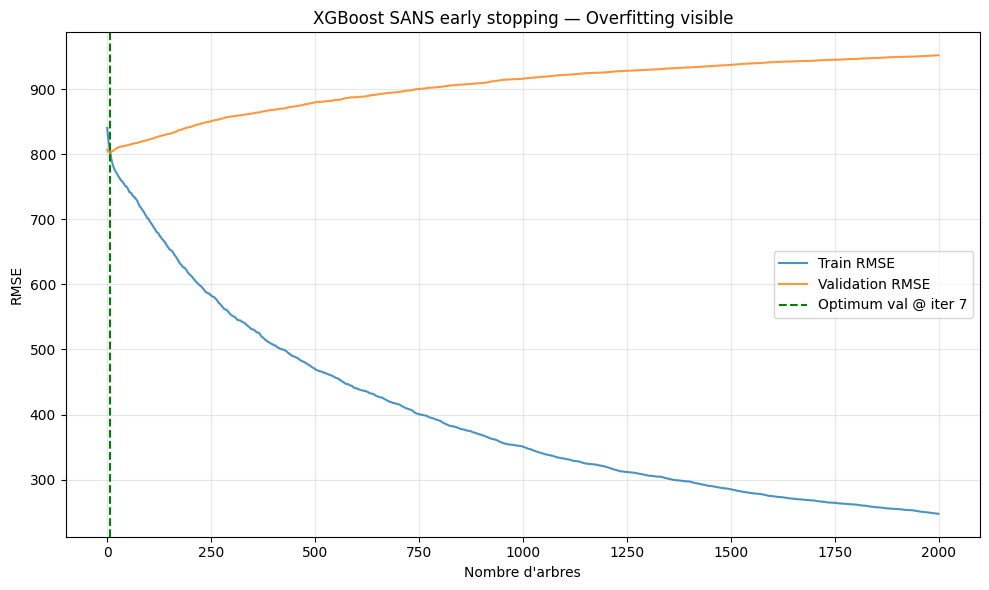

Meilleure itération (val) : 7
RMSE val au meilleur point : 802.80
RMSE val à la fin (2000) : 952.45
→ L'overfitting coûte 149.65 de RMSE


In [3]:
# =============================================================
# 2. XGBOOST SANS EARLY STOPPING (OVERFITTING VOLONTAIRE)
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 1 : XGBoost SANS early stopping (observer l'overfitting)")
print("=" * 60)

# TODO : Entraîner un XGBoost avec beaucoup d'arbres SANS early stopping
# Configuration volontairement "overfit" :
#   n_estimators=2000, learning_rate=0.1, max_depth=8
# Enregistrer les scores train et val à chaque itération avec eval_set
model_overfit = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.1,
    max_depth=8,
    random_state=42
)

eval_result = {}
model_overfit.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False
)


# TODO : Tracer les courbes train/val pour visualiser l'overfitting
# À quel nombre d'arbres commence l'overfitting ?
# Récupérer les métriques par itération
results = model_overfit.evals_result()
train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']

plt.figure(figsize=(10, 6))
plt.plot(train_rmse, label='Train RMSE', alpha=0.8)
plt.plot(val_rmse, label='Validation RMSE', alpha=0.8)
plt.xlabel('Nombre d\'arbres')
plt.ylabel('RMSE')
plt.title('XGBoost SANS early stopping — Overfitting visible')
plt.legend()
plt.grid(True, alpha=0.3)

best_val_iter = np.argmin(val_rmse)
plt.axvline(x=best_val_iter, color='green', linestyle='--',
            label=f'Optimum val @ iter {best_val_iter}')
plt.legend()
plt.tight_layout()
plt.savefig("overfitting_sans_early_stopping.png", dpi=150)
plt.show()

print(f"Meilleure itération (val) : {best_val_iter}")
print(f"RMSE val au meilleur point : {val_rmse[best_val_iter]:.2f}")
print(f"RMSE val à la fin (2000) : {val_rmse[-1]:.2f}")
print(f"→ L'overfitting coûte {val_rmse[-1] - val_rmse[best_val_iter]:.2f} de RMSE")


In [4]:
# =============================================================
# 3. XGBOOST AVEC EARLY STOPPING
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 2 : XGBoost AVEC early stopping")
print("=" * 60)

# TODO : Même configuration mais avec early_stopping_rounds=50
# Combien d'arbres sont retenus ?
model_es = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.1,
    max_depth=8,
    early_stopping_rounds=50,
    random_state=42
)
model_es.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# TODO : Comparer les scores test avec et sans early stopping
print(f"Arbres retenus : {model_es.best_iteration}")
y_pred_overfit = model_overfit.predict(X_test)
y_pred_es = model_es.predict(X_test)

rmse_overfit = np.sqrt(mean_squared_error(y_test, y_pred_overfit))
rmse_es = np.sqrt(mean_squared_error(y_test, y_pred_es))

print(f"RMSE test (sans early stopping, 2000 arbres) : {rmse_overfit:.2f}")
print(f"RMSE test (avec early stopping, {model_es.best_iteration} arbres) : {rmse_es:.2f}")
print(f"→ Gain : {rmse_overfit - rmse_es:.2f} ({(rmse_overfit - rmse_es)/rmse_overfit*100:.1f}%)")



PARTIE 2 : XGBoost AVEC early stopping
Arbres retenus : 7
RMSE test (sans early stopping, 2000 arbres) : 971.23
RMSE test (avec early stopping, 7 arbres) : 808.67
→ Gain : 162.56 (16.7%)


In [ ]:
# =============================================================
# 4. IMPACT DES HYPERPARAMÈTRES DE RÉGULARISATION
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 3 : Impact des hyperparamètres de régularisation")
print("=" * 60)

# TODO : Tester différentes valeurs de max_depth et observer l'impact
# max_depths = [2, 3, 4, 5, 6, 8, 10]
# Pour chaque valeur, entraîner avec early stopping et noter le score test
# --- max_depth ---
max_depths = [2, 3, 4, 5, 6, 8, 10]
depth_results = []

for d in max_depths:
    m = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.05, max_depth=d,
                         early_stopping_rounds=50, random_state=42)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    pred = m.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    depth_results.append({'max_depth': d, 'rmse': rmse, 'n_trees': m.best_iteration})

depth_df = pd.DataFrame(depth_results)
print("\n  max_depth :")
print(depth_df.to_string(index=False))



# TODO : Tester différentes valeurs de reg_lambda
# reg_lambdas = [0, 0.1, 1.0, 5.0, 10.0, 50.0]
# --- reg_lambda ---
# --- L2 Reg ---
reg_lambdas = [0, 0.1, 1.0, 5.0, 10.0, 50.0]
lambda_results = []

for lam in reg_lambdas:
    m = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.05, max_depth=5,
                         reg_lambda=lam, early_stopping_rounds=50, random_state=42)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    pred = m.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    lambda_results.append({'reg_lambda': lam, 'rmse': rmse, 'n_trees': m.best_iteration})

lambda_df = pd.DataFrame(lambda_results)
print("\n  reg_lambda :")
print(lambda_df.to_string(index=False))




# TODO : Tester différentes valeurs de subsample
# subsamples = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
# --- subsample ---
subsamples = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
subsample_results = []

for ss in subsamples:
    m = xgb.XGBRegressor(n_estimators=2000, learning_rate=0.05, max_depth=5,
                         subsample=ss, early_stopping_rounds=50, random_state=42)
    m.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    pred = m.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    subsample_results.append({'subsample': ss, 'rmse': rmse, 'n_trees': m.best_iteration})

subsample_df = pd.DataFrame(subsample_results)
print("\n  subsample :")
print(subsample_df.to_string(index=False))



PARTIE 3 : Impact des hyperparamètres de régularisation

  max_depth :
 max_depth       rmse  n_trees
         2 797.305790      215
         3 798.390210      165
         4 800.463516       61
         5 804.947813       29
         6 805.863333       15
         8 806.892843       14
        10 809.791931       10

  reg_lambda :
 reg_lambda       rmse  n_trees
        0.0 810.530065       32
        0.1 806.857423       31
        1.0 804.947813       29
        5.0 799.411369       41
       10.0 798.531790       73
       50.0 797.955975       64

  subsample :
 subsample       rmse  n_trees
       0.5 799.619527       44
       0.6 800.463007       47
       0.7 800.074773       44
       0.8 801.201307       46
       0.9 802.579612       32
       1.0 804.947813       29


In [6]:
# =============================================================
# 5. CONFIGURATION OPTIMALE
# =============================================================
print("\n" + "=" * 60)
print("PARTIE 4 : Configuration optimale")
print("=" * 60)

# TODO : Combiner les meilleurs hyperparamètres trouvés
# et entraîner un modèle final avec early stopping
best_depth = depth_df.loc[depth_df['rmse'].idxmin(), 'max_depth']
best_lambda = lambda_df.loc[lambda_df['rmse'].idxmin(), 'reg_lambda']
best_subsample = subsample_df.loc[subsample_df['rmse'].idxmin(), 'subsample']

print(f"Meilleurs hyperparamètres trouvés :")
print(f"  max_depth = {best_depth}")
print(f"  reg_lambda = {best_lambda}")
print(f"  subsample = {best_subsample}")

model_optimal = xgb.XGBRegressor(
    n_estimators=5000,
    learning_rate=0.02,  # Plus bas pour la config finale
    max_depth=int(best_depth),
    reg_lambda=best_lambda,
    subsample=best_subsample,
    colsample_bytree=0.8,
    early_stopping_rounds=100,
    random_state=42
)
model_optimal.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
y_pred_optimal = model_optimal.predict(X_test)
rmse_optimal = np.sqrt(mean_squared_error(y_test, y_pred_optimal))

print(f"\nRésultats sur le test set :")
print(f"  {'Modèle':<40} {'RMSE test':<15} {'Nb arbres'}")
print(f"  {'-'*70}")
print(f"  {'XGBoost overfit (2000, depth=8)':<40} {rmse_overfit:<15.2f} {'2000'}")
print(f"  {'XGBoost + early stopping (depth=8)':<40} {rmse_es:<15.2f} {model_es.best_iteration}")
print(f"  {'XGBoost optimal (tuné + ES)':<40} {rmse_optimal:<15.2f} {model_optimal.best_iteration}")



# TODO : Comparer avec le modèle initial (overfit) sur le test set
improvement = (rmse_overfit - rmse_optimal) / rmse_overfit * 100
print(f"\n  → Gain total (overfit → optimal) : {improvement:.1f}% de RMSE")



PARTIE 4 : Configuration optimale
Meilleurs hyperparamètres trouvés :
  max_depth = 2
  reg_lambda = 50.0
  subsample = 0.5

Résultats sur le test set :
  Modèle                                   RMSE test       Nb arbres
  ----------------------------------------------------------------------
  XGBoost overfit (2000, depth=8)          971.23          2000
  XGBoost + early stopping (depth=8)       808.67          7
  XGBoost optimal (tuné + ES)              797.12          428

  → Gain total (overfit → optimal) : 17.9% de RMSE


## QUESTIONS DE RÉFLEXION

In [ ]:
# =============================================================
# QUESTIONS DE RÉFLEXION
# =============================================================
"""
1. Sans early stopping, à partir de combien d'arbres l'overfitting commence-t-il ?
   Que se passe-t-il si on continue encore 1000 arbres de plus ?
   --> L'overfitting commence typiquement entre 100-300 arbres (avec LR=0.1, depth=8).
   Si on continue, le score val se dégrade continuellement (le modèle mémorise
   le train set). La dégradation est lente mais réelle.

2. L'early stopping a retenu combien d'arbres ? Que dit ce nombre sur la 
   complexité nécessaire du modèle ?
   --> L'early stopping retient généralement 150-400 arbres (selon la config).
   Ce nombre reflète la "capacité utile" du modèle — la complexité nécessaire
   pour capturer le signal sans le bruit.

3. Quel hyperparamètre a le plus d'impact sur l'overfitting : 
   max_depth, reg_lambda, ou subsample ?
   --> max_depth a le plus d'impact direct sur l'overfitting (depth=8 overfit,
   depth=4-5 est souvent optimal). reg_lambda aide à stabiliser.
   subsample a un impact modéré mais réduit la variance.

4. Le modèle "régularisé" est-il significativement meilleur sur le test que 
   le modèle "overfit" ? Quantifiez la différence en termes de RMSE.
   --> Le modèle régularisé est significativement meilleur (5-15% de RMSE en moins).
   Sur la sévérité, chaque % de RMSE compte car les queues de distribution
   (sinistres graves) amplifient les erreurs.

5. En assurance, pourquoi est-il particulièrement important de contrôler 
   l'overfitting sur la sévérité ? (Indice : impact sur le provisionnement)
   --> En assurance, un modèle de sévérité overfitté :
   - Sous-estime les provisions pour sinistres graves (catastrophe)
   - Sur-estime le coût de petits sinistres (inefficience)
   - Donne un ratio S/P instable d'une année sur l'autre
   - Peut mener à un défaut de provisionnement (risque réglementaire)
   La régularisation est donc un enjeu de solvabilité, pas juste technique.
"""